In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (16, 9)
plt.style.use('fast')

from keras.models import Sequential
from keras.layers import Dense,Activation,Flatten
from sklearn.preprocessing import MinMaxScaler

from keras.layers import Input, Embedding, Dense, Flatten, Dropout, concatenate, LSTM
from keras.layers import BatchNormalization, SpatialDropout1D
from keras.callbacks import Callback
from keras.models import Model

import keras as keras

df = pd.read_csv('diarios_baselimpia(arreglada).csv',  parse_dates=[0], header=None, index_col=0,
                 names=['Fecha','Contagios diarios','Contagios acumulados','Muertes diarias','Muertes acumuladas'])
df.head()

,Contagios diarios,Contagios acumulados,Muertes diarias,Muertes acumuladas
Fecha,,,,
2020-01-06,13,38,0,0
2020-01-07,29,67,0,0
2020-01-08,24,91,0,0
2020-01-09,21,112,0,0
2020-01-10,7,119,0,0


In [2]:
df['weekday']=[x.weekday() for x in df.index]
df['month']=[x.month for x in df.index]
df.head()

,Contagios diarios,Contagios acumulados,Muertes diarias,Muertes acumuladas,weekday,month
Fecha,,,,,,
2020-01-06,13,38,0,0,0,1
2020-01-07,29,67,0,0,1,1
2020-01-08,24,91,0,0,2,1
2020-01-09,21,112,0,0,3,1
2020-01-10,7,119,0,0,4,1


In [3]:
df.describe()

,Contagios diarios,Contagios acumulados,Muertes diarias,Muertes acumuladas,weekday,month
count,361.000000,3.610000e+02,361.000000,361.000000,361.000000,361.000000
mean,4942.614958,4.933727e+05,137.351801,14805.501385,2.983380,6.590028
std,4797.902766,5.239504e+05,102.192280,15172.168441,2.001319,3.417814
min,3.000000,3.800000e+01,0.000000,0.000000,0.000000,1.000000
25%,760.000000,1.429900e+04,13.000000,161.000000,1.000000,4.000000
50%,3452.000000,2.979100e+05,158.000000,9855.000000,3.000000,7.000000
75%,8000.000000,8.853160e+05,208.000000,27066.000000,5.000000,10.000000
max,20964.000000,1.784309e+06,406.000000,49584.000000,6.000000,12.000000


In [4]:
#Preprocesdo de los datos

PASOS=7
# convert series to supervised learning
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    n_vars = 1 if type(data) is list else data.shape[1]
    df = pd.DataFrame(data)
    cols, names = list(), list()
    # input sequence (t-n, ... t-1)
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
    # forecast sequence (t, t+1, ... t+n)
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        if i == 0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
    # put it all together
    agg = pd.concat(cols, axis=1)
    agg.columns = names
    # drop rows with NaN values
    if dropnan:
        agg.dropna(inplace=True)
    return agg

In [5]:
# load dataset
values = df['Contagios diarios'].values

# ensure all data is float
values = values.astype('float32')
# normalize features
scaler = MinMaxScaler(feature_range=(-1, 1))

values=values.reshape(-1, 1) # esto lo hacemos porque tenemos 1 sola dimension

scaled = scaler.fit_transform(values)

reframed = series_to_supervised(scaled, PASOS, 1)
reframed.reset_index(inplace=True, drop=True)

contador=0
reframed['weekday']=df['weekday']
reframed['month']=df['month']
reframed['Muertes diarias']=df['Muertes diarias']

for i in range(reframed.index[0],reframed.index[-1]):
    reframed['weekday'].loc[contador]=df['weekday'][i+8]
    reframed['month'].loc[contador]=df['month'][i+8]
    reframed['Muertes diarias'].loc[contador]=df['Muertes diarias'][i+8]
    contador=contador+1
reframed.head()

/home/enrique/anaconda3/lib/python3.7/site-packages/pandas/core/indexing.py:671: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_with_indexer(indexer, value)


,var1(t-7),var1(t-6),var1(t-5),var1(t-4),var1(t-3),var1(t-2),var1(t-1),var1(t),weekday,month,Muertes diarias
0,-0.999046,-0.997519,-0.997996,-0.998282,-0.999618,-0.999714,-0.999237,-0.998473,1.0,1.0,3.0
1,-0.997519,-0.997996,-0.998282,-0.999618,-0.999714,-0.999237,-0.998473,-0.997805,2.0,1.0,1.0
2,-0.997996,-0.998282,-0.999618,-0.999714,-0.999237,-0.998473,-0.997805,-0.997424,3.0,1.0,0.0
3,-0.998282,-0.999618,-0.999714,-0.999237,-0.998473,-0.997805,-0.997424,-0.997233,4.0,1.0,0.0
4,-0.999618,-0.999714,-0.999237,-0.998473,-0.997805,-0.997424,-0.997233,-0.997996,5.0,1.0,0.0


In [6]:
reordenado=reframed[ ['weekday','month','Muertes diarias','var1(t-7)','var1(t-6)','var1(t-5)','var1(t-4)','var1(t-3)','var1(t-2)','var1(t-1)','var1(t)'] ]
reordenado.dropna(inplace=True)
reordenado

/home/enrique/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


,weekday,month,Muertes diarias,var1(t-7),var1(t-6),var1(t-5),var1(t-4),var1(t-3),var1(t-2),var1(t-1),var1(t)
0,1.0,1.0,3.0,-0.999046,-0.997519,-0.997996,-0.998282,-0.999618,-0.999714,-0.999237,-0.998473
1,2.0,1.0,1.0,-0.997519,-0.997996,-0.998282,-0.999618,-0.999714,-0.999237,-0.998473,-0.997805
2,3.0,1.0,0.0,-0.997996,-0.998282,-0.999618,-0.999714,-0.999237,-0.998473,-0.997805,-0.997424
3,4.0,1.0,0.0,-0.998282,-0.999618,-0.999714,-0.999237,-0.998473,-0.997805,-0.997424,-0.997233
4,5.0,1.0,0.0,-0.999618,-0.999714,-0.999237,-0.998473,-0.997805,-0.997424,-0.997233,-0.997996
...,...,...,...,...,...,...,...,...,...,...,...
348,6.0,12.0,370.0,-0.154430,-0.665951,0.839225,0.752206,0.686275,0.294976,-0.800964,-0.410620
349,0.0,12.0,394.0,-0.665951,0.839225,0.752206,0.686275,0.294976,-0.800964,-0.410620,-0.632460
350,1.0,12.0,406.0,0.839225,0.752206,0.686275,0.294976,-0.800964,-0.410620,-0.632460,0.917370
351,2.0,12.0,365.0,0.752206,0.686275,0.294976,-0.800964,-0.410620,-0.632460,0.917370,1.000000


In [7]:
#Dividiendo en set de Entrenamiento y Validación

training_data = reordenado.drop('var1(t)',axis=1)#.values
target_data=reordenado['var1(t)']
#training_data.head()
valid_data = training_data[353-62:353]
valid_target=target_data[353-62:353]

training_data = training_data[0:353]
target_data=target_data[0:353]
print(training_data.shape,target_data.shape,valid_data.shape,valid_target.shape)
#training_data.head()

(353, 10) (353,) (62, 10) (62,)


In [8]:
#Optimizadores 

opt = keras.optimizers.Adam(
    learning_rate=0.01,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-08,
    amsgrad=False,
    name="Adam",
)

opt1 = keras.optimizers.Adadelta(
    learning_rate=0.001, 
    rho=0.95, 
    epsilon=1e-07, 
    name="Adadelta",
)

opt2 = keras.optimizers.Adagrad(
    learning_rate=0.001,
    initial_accumulator_value=0.1,
    epsilon=1e-07,
    name="Adagrad",
)

opt3 = keras.optimizers.Adamax(
    learning_rate=0.002, 
    beta_1=0.9, 
    beta_2=0.999, 
    epsilon=1e-07, 
    name="Adamax",
)
m = 0  # Initialize initial 1st moment vector
v = 0  # Initialize the exponentially weighted infinity norm
t = 0  # Initialize timestep


opt4 = keras.optimizers.Nadam(
    learning_rate=0.001, 
    beta_1=0.9, 
    beta_2=0.999, 
    epsilon=1e-07, 
    name="Nadam",
)


In [9]:
#Creamos el Modelo de Red Neuronal
#Utilizando una Red Feedforward con Embeddings

def crear_modeloEmbeddings():
    emb_dias = 2 #tamaño profundidad de embeddings
    emb_meses = 4
    
    in_dias = Input(shape=[1], name = 'dias')
    emb_dias = Embedding(7+1, emb_dias)(in_dias)
    in_meses = Input(shape=[1], name = 'meses')
    emb_meses = Embedding(12+1, emb_meses)(in_meses)
    
    in_diarios = Input(shape=[PASOS], name = 'diarios')
    in_muertes = Input(shape=[PASOS], name = 'muertes')

    fe = concatenate([(emb_dias), (emb_meses)])

    x = Flatten()(fe)
    x = Dense(PASOS,activation='tanh')(x)
    outp = Dense(1,activation='tanh')(x)
    model = Model(inputs=[in_dias,in_meses,in_diarios,in_muertes], outputs=outp)

    
    model.compile(loss='mean_absolute_error', 
                  optimizer=opt,
                  metrics=['MSE'])

    model.summary()
    return model

In [10]:
#Entrenamiento

EPOCHS=165

model = crear_modeloEmbeddings()

continuas=training_data[['var1(t-7)','var1(t-6)','var1(t-5)','var1(t-4)','var1(t-3)','var1(t-2)','var1(t-1)']]
valid_continuas=valid_data[['var1(t-7)','var1(t-6)','var1(t-5)','var1(t-4)','var1(t-3)','var1(t-2)','var1(t-1)']]

history=model.fit([training_data['weekday'],training_data['month'],training_data['Muertes diarias'],continuas], target_data, epochs=EPOCHS
                 ,validation_data=([valid_data['weekday'],valid_data['month'],valid_data['Muertes diarias'],valid_continuas],valid_target))

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
dias (InputLayer)               [(None, 1)]          0                                            
__________________________________________________________________________________________________
meses (InputLayer)              [(None, 1)]          0                                            
__________________________________________________________________________________________________
embedding (Embedding)           (None, 1, 2)         16          dias[0][0]                       
__________________________________________________________________________________________________
embedding_1 (Embedding)         (None, 1, 4)         52          meses[0][0]                      
______________________________________________________________________________________________

12/12 [==============================] - 0s 27ms/step - loss: 0.0738 - MSE: 0.0182 - val_loss: 0.1696 - val_MSE: 0.0717
Epoch 39/165
12/12 [==============================] - 0s 24ms/step - loss: 0.0689 - MSE: 0.0170 - val_loss: 0.1556 - val_MSE: 0.0659
Epoch 40/165
12/12 [==============================] - 0s 16ms/step - loss: 0.0769 - MSE: 0.0179 - val_loss: 0.1686 - val_MSE: 0.0682
Epoch 41/165
12/12 [==============================] - 0s 14ms/step - loss: 0.0677 - MSE: 0.0159 - val_loss: 0.1632 - val_MSE: 0.0728
Epoch 42/165
12/12 [==============================] - 0s 24ms/step - loss: 0.0699 - MSE: 0.0189 - val_loss: 0.1678 - val_MSE: 0.0743
Epoch 43/165
12/12 [==============================] - 0s 25ms/step - loss: 0.0686 - MSE: 0.0181 - val_loss: 0.1489 - val_MSE: 0.0650
Epoch 44/165
12/12 [==============================] - 0s 23ms/step - loss: 0.0714 - MSE: 0.0173 - val_loss: 0.1655 - val_MSE: 0.0681
Epoch 45/165
12/12 [==============================] - 0s 15ms/step - loss: 0.0837 

Epoch 100/165
12/12 [==============================] - 0s 15ms/step - loss: 0.0698 - MSE: 0.0182 - val_loss: 0.1361 - val_MSE: 0.0643
Epoch 101/165
12/12 [==============================] - 0s 14ms/step - loss: 0.0736 - MSE: 0.0178 - val_loss: 0.1446 - val_MSE: 0.0629
Epoch 102/165
12/12 [==============================] - 0s 16ms/step - loss: 0.0751 - MSE: 0.0195 - val_loss: 0.1392 - val_MSE: 0.0654
Epoch 103/165
12/12 [==============================] - 0s 15ms/step - loss: 0.0736 - MSE: 0.0186 - val_loss: 0.1447 - val_MSE: 0.0686
Epoch 104/165
12/12 [==============================] - 0s 16ms/step - loss: 0.0759 - MSE: 0.0199 - val_loss: 0.1380 - val_MSE: 0.0648
Epoch 105/165
12/12 [==============================] - 0s 14ms/step - loss: 0.0600 - MSE: 0.0152 - val_loss: 0.1302 - val_MSE: 0.0629
Epoch 106/165
12/12 [==============================] - 0s 15ms/step - loss: 0.0586 - MSE: 0.0148 - val_loss: 0.1324 - val_MSE: 0.0610
Epoch 107/165
12/12 [==============================] - 0s 25ms

Epoch 161/165
12/12 [==============================] - 0s 14ms/step - loss: 0.0574 - MSE: 0.0150 - val_loss: 0.1423 - val_MSE: 0.0609
Epoch 162/165
12/12 [==============================] - 0s 14ms/step - loss: 0.0650 - MSE: 0.0166 - val_loss: 0.1352 - val_MSE: 0.0625
Epoch 163/165
12/12 [==============================] - 0s 14ms/step - loss: 0.0581 - MSE: 0.0153 - val_loss: 0.1367 - val_MSE: 0.0618
Epoch 164/165
12/12 [==============================] - 0s 13ms/step - loss: 0.0585 - MSE: 0.0153 - val_loss: 0.1360 - val_MSE: 0.0658
Epoch 165/165
12/12 [==============================] - 0s 13ms/step - loss: 0.0588 - MSE: 0.0153 - val_loss: 0.1295 - val_MSE: 0.0624


62


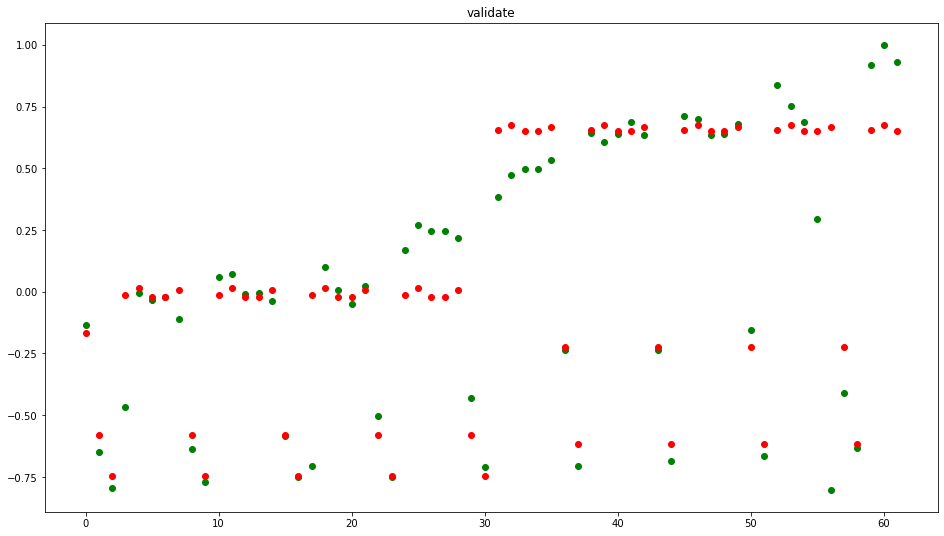

In [11]:
#Visualizacion de resultados

results=model.predict([valid_data['weekday'],valid_data['month'],valid_data['Muertes diarias'],valid_continuas])
print( len(results) )
plt.scatter(range(len(valid_target)),valid_target,c='g')
plt.scatter(range(len(results)),results,c='r')
plt.title('validate')
plt.show()

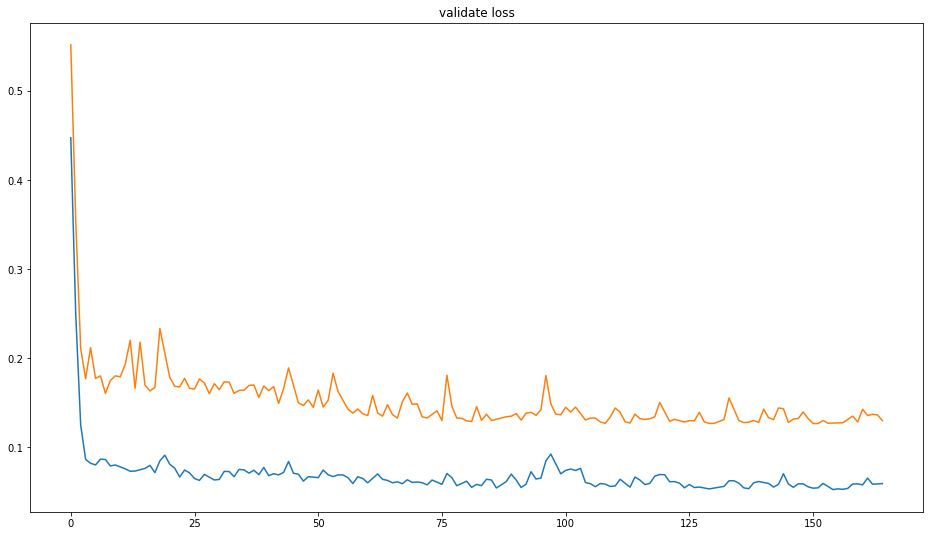

In [12]:
plt.plot(history.history['loss'])
plt.title('loss')
plt.plot(history.history['val_loss'])
plt.title('validate loss')
plt.show()

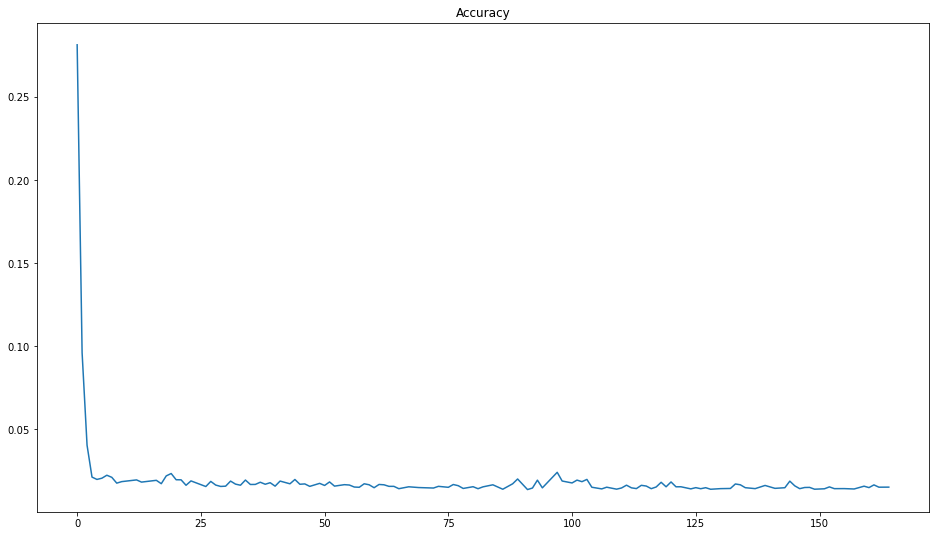

In [13]:
plt.title('Accuracy')
plt.plot(history.history['MSE'])
plt.show()

In [14]:
compara = pd.DataFrame(np.array([valid_target, [x[0] for x in results]])).transpose()
compara.columns = ['real', 'prediccion']

inverted = scaler.inverse_transform(compara.values)

compara2 = pd.DataFrame(inverted)
compara2.columns = ['real', 'prediccion']
compara2['diferencia'] = compara2['real'] - compara2['prediccion']
compara2.head(12)

,real,prediccion,diferencia
0,9065.000000,8741.155273,323.844727
1,3676.000244,4394.667480,-718.667236
2,2136.000000,2652.153320,-516.153320
3,5602.000000,10326.194336,-4724.194336
4,10431.000000,10643.028320,-212.028320
5,10119.000000,10280.092773,-161.092773
6,10252.000000,10278.980469,-26.980469
7,9337.000000,10570.544922,-1233.544922
8,3825.000488,4394.667480,-569.666992
9,2419.999756,2652.153320,-232.153564


In [15]:
compara2.describe()

,real,prediccion,diferencia
count,62.000000,62.000000,62.000000
mean,11009.225586,11310.878906,-301.651184
std,5712.599609,5347.346680,2621.691162
min,2089.000244,2652.153320,-15404.845703
25%,5694.000000,8150.714355,-556.288574
50%,10644.999512,10448.369629,-70.226562
75%,16636.250000,17319.292969,588.784668
max,20963.998047,17540.207031,3423.791016


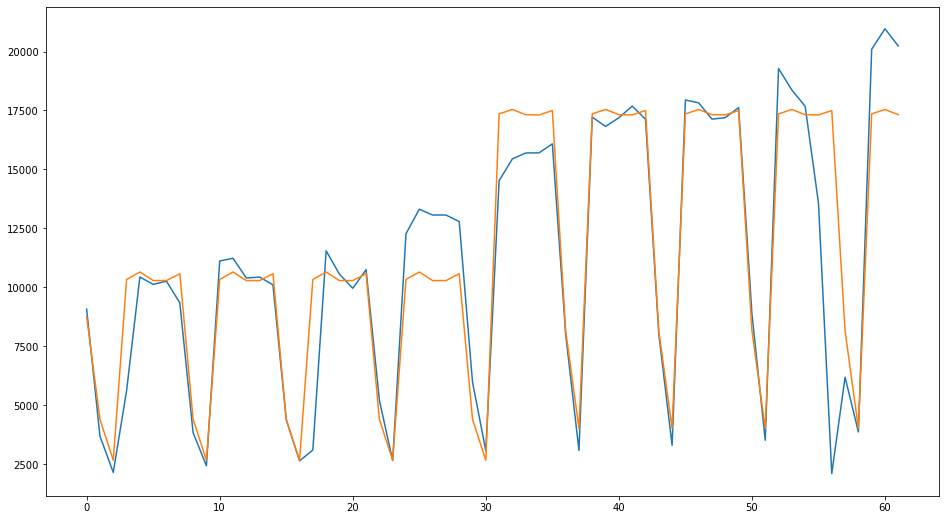

In [16]:
compara2['real'].plot()
compara2['prediccion'].plot()

In [17]:
#Pronostico
df1 = pd.read_csv('diarios_baselimpiaP.csv',  parse_dates=[0], header=None, index_col=0, 
                 names=['Fecha','Contagios diarios','Contagios acumulados','Muertes diarias','Muertes acumuladas'])
df1['weekday']=[x.weekday() for x in df1.index]
df1['month']=[x.month for x in df1.index]
df1.head()

,Contagios diarios,Contagios acumulados,Muertes diarias,Muertes acumuladas,weekday,month
Fecha,,,,,,
2020-01-06,13,38,0,0,0,1
2020-01-07,29,67,0,0,1,1
2020-01-08,24,91,0,0,2,1
2020-01-09,21,112,0,0,3,1
2020-01-10,7,119,0,0,4,1


In [18]:

ultimosDias = df1['2021-02-01':'2021-02-14']
ultimosDias

,Contagios diarios,Contagios acumulados,Muertes diarias,Muertes acumuladas,weekday,month
Fecha,,,,,,
2021-02-01,5448,2236436,417,62652,0,2
2021-02-02,4384,2240820,398,63050,1,2
2021-02-03,12153,2252973,344,63394,2,2
2021-02-04,13575,2266548,281,63675,3,2
2021-02-05,13051,2279599,165,63840,4,2
2021-02-06,13209,2292808,272,64112,5,2
2021-02-07,6065,2298873,312,64424,6,2
2021-02-08,3868,2302741,323,64747,0,2
2021-02-09,10738,2313479,340,65087,1,2


In [19]:
#Preparando datos para el test

# load dataset
values = ultimosDias['Contagios diarios'].values

# ensure all data is float
values = values.astype('float32')
# normalize features
#scaler = MinMaxScaler(feature_range=(-1, 1))

values=values.reshape(-1, 1) # esto lo hacemos porque tenemos 1 sola dimension

scaled = scaler.fit_transform(values)

reframed = series_to_supervised(scaled, PASOS, 1)
reframed.reset_index(inplace=True, drop=True)

contador=0
reframed['weekday']=ultimosDias['weekday']
reframed['month']=ultimosDias['month']
reframed['Muertes diarias']=ultimosDias['Muertes diarias']

for i in range(reframed.index[0],reframed.index[-1]):
    reframed['weekday'].loc[contador]=ultimosDias['weekday'][i+8]
    reframed['month'].loc[contador]=ultimosDias['month'][i+8]
    reframed['Muertes diarias'].loc[contador]=ultimosDias['Muertes diarias'][i+8]

    contador=contador+1
reframed.head()

reordenado=reframed[ ['weekday','month','Muertes diarias','var1(t-7)','var1(t-6)','var1(t-5)','var1(t-4)','var1(t-3)','var1(t-2)','var1(t-1)'] ]
reordenado.dropna(inplace=True)
reordenado

/home/enrique/anaconda3/lib/python3.7/site-packages/pandas/core/indexing.py:671: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_with_indexer(indexer, value)
/home/enrique/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


,weekday,month,Muertes diarias,var1(t-7),var1(t-6),var1(t-5),var1(t-4),var1(t-3),var1(t-2),var1(t-1)
0,1.0,2.0,340.0,-0.674462,-0.893685,0.707016,1.000000,0.892037,0.924590,-0.547337
1,2.0,2.0,301.0,-0.893685,0.707016,1.000000,0.892037,0.924590,-0.547337,-1.000000
2,3.0,2.0,265.0,0.707016,1.000000,0.892037,0.924590,-0.547337,-1.000000,0.415473
3,4.0,2.0,261.0,1.000000,0.892037,0.924590,-0.547337,-1.000000,0.415473,0.497888
4,5.0,2.0,268.0,0.892037,0.924590,-0.547337,-1.000000,0.415473,0.497888,0.402905
5,6.0,2.0,302.0,0.924590,-0.547337,-1.000000,0.415473,0.497888,0.402905,0.343361


In [20]:
values = reordenado.values
x_test = values[5:, :]
x_test = x_test.reshape((x_test.shape[0], 1, x_test.shape[1]))
print(x_test.shape)
print(x_test)
ultDiaSemana = reordenado.weekday[len(reordenado.index)-1]
ultDiaSemana

(1, 1, 10)
[[[  6.           2.         302.           0.92459047  -0.54733694
    -1.           0.41547334   0.49788821   0.40290511   0.34336054]]]


6.0

In [21]:
def agregarNuevoValor(x_test,nuevoValor,ultDiaSemana):
    for i in range(x_test.shape[2]-3):
        x_test[0][0][i+2] = x_test[0][0][i+3]
    ultDiaSemana=ultDiaSemana+1
    if ultDiaSemana>6:
        ultDiaSemana=0
    x_test[0][0][0]=ultDiaSemana
    x_test[0][0][1]=12
    x_test[0][0][x_test.shape[2]-1]=nuevoValor
    return x_test,ultDiaSemana

In [22]:
#Pronostico para la siguiente semana

results=[]
for i in range(7):
    dia=np.array([x_test[0][0][0]])
    mes=np.array([x_test[0][0][1]])
    valores=np.array([x_test[0][0][2:9]])
    parcial=model.predict([dia, mes, valores])
    results.append(parcial[0])
    print('pred',i,x_test)
    x_test,ultDiaSemana=agregarNuevoValor(x_test,parcial[0],ultDiaSemana)

pred 0 [[[  6.           2.         302.           0.92459047  -0.54733694
    -1.           0.41547334   0.49788821   0.40290511   0.34336054]]]
pred 1 [[[ 0.         12.          0.92459047 -0.54733694 -1.
    0.41547334  0.49788821  0.40290511  0.34336054 -0.99427825]]]
pred 2 [[[ 1.         12.         -0.54733694 -1.          0.41547334
    0.49788821  0.40290511  0.34336054 -0.99427825 -0.61797947]]]
pred 3 [[[ 2.         12.         -1.          0.41547334  0.49788821
    0.40290511  0.34336054 -0.99427825 -0.61797947  0.65541822]]]
pred 4 [[[ 3.         12.          0.41547334  0.49788821  0.40290511
    0.34336054 -0.99427825 -0.61797947  0.65541822  0.67331779]]]
pred 5 [[[ 4.         12.          0.49788821  0.40290511  0.34336054
   -0.99427825 -0.61797947  0.65541822  0.67331779  0.65223926]]]
pred 6 [[[ 5.         12.          0.40290511  0.34336054 -0.99427825
   -0.61797947  0.65541822  0.67331779  0.65223926  0.6513021 ]]]


In [23]:
adimen = [x for x in results]    
print(adimen)
inverted = scaler.inverse_transform(adimen)
inverted

[array([-0.99427825], dtype=float32), array([-0.61797947], dtype=float32), array([0.6554182], dtype=float32), array([0.6733178], dtype=float32), array([0.65223926], dtype=float32), array([0.6513021], dtype=float32), array([0.66889423], dtype=float32)]


array([[ 3895.77061191],
       [ 5722.13671732],
       [11902.57221264],
       [11989.44778715],
       [11887.14315921],
       [11882.59463468],
       [11967.97804551]])

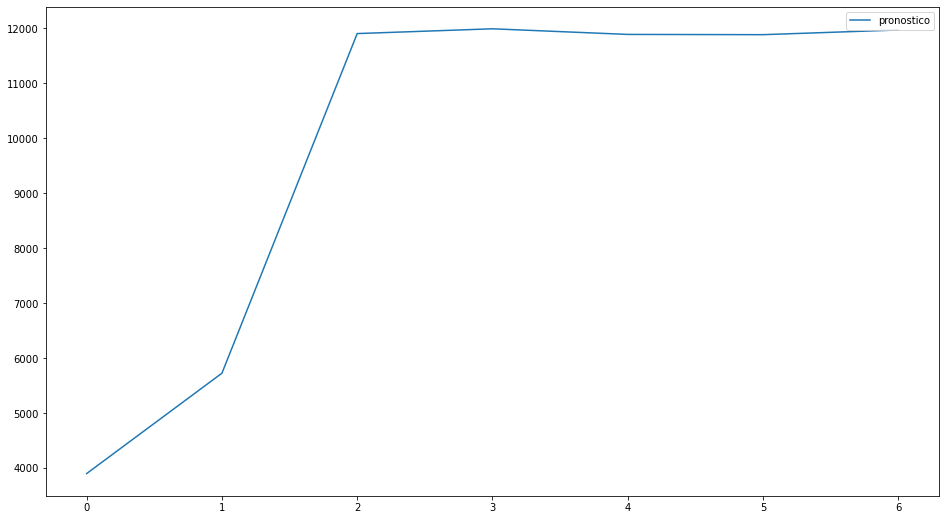

In [24]:
#Visualizacion del pronostico

prediccionSiguienteSemana = pd.DataFrame(inverted)
prediccionSiguienteSemana.columns = ['pronostico']
prediccionSiguienteSemana.plot()
prediccionSiguienteSemana.to_csv('pronostico_arreglada_diarios19.csv')

In [25]:
prediccionSiguienteSemana

,pronostico
0,3895.770612
1,5722.136717
2,11902.572213
3,11989.447787
4,11887.143159
5,11882.594635
6,11967.978046
